# Garbage Classification using MobileNetV2

This project classifies garbage images into multiple categories using Deep Learning and Transfer Learning with MobileNetV2.

## Technologies Used
- TensorFlow / Keras
- MobileNetV2
- OpenCV
- Gradio
- Google Colab

In [1]:
!pip install opencv-python kagglehub gradio -q

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

from sklearn.metrics import confusion_matrix, classification_report

In [3]:


import kagglehub

path = kagglehub.dataset_download("mostafaabla/garbage-classification")

print(path)

Using Colab cache for faster access to the 'garbage-classification' dataset.
/kaggle/input/garbage-classification


In [4]:
import os

os.listdir(path)

['garbage_classification']

In [5]:
dataset_path = os.path.join(path, "garbage_classification")
os.listdir(dataset_path)

['metal',
 'white-glass',
 'biological',
 'paper',
 'brown-glass',
 'battery',
 'trash',
 'cardboard',
 'shoes',
 'clothes',
 'plastic',
 'green-glass']

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [7]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,

    validation_split=0.2,

    rotation_range=25,
    zoom_range=0.25,

    width_shift_range=0.2,
    height_shift_range=0.2,

    horizontal_flip=True,

    brightness_range=[0.8,1.2]
)

In [8]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 12415 images belonging to 12 classes.


In [9]:
validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 3100 images belonging to 12 classes.


In [10]:
print("Classes:", train_generator.class_indices)

print("Training Samples:", train_generator.samples)

print("Validation Samples:", validation_generator.samples)

Classes: {'battery': 0, 'biological': 1, 'brown-glass': 2, 'cardboard': 3, 'clothes': 4, 'green-glass': 5, 'metal': 6, 'paper': 7, 'plastic': 8, 'shoes': 9, 'trash': 10, 'white-glass': 11}
Training Samples: 12415
Validation Samples: 3100


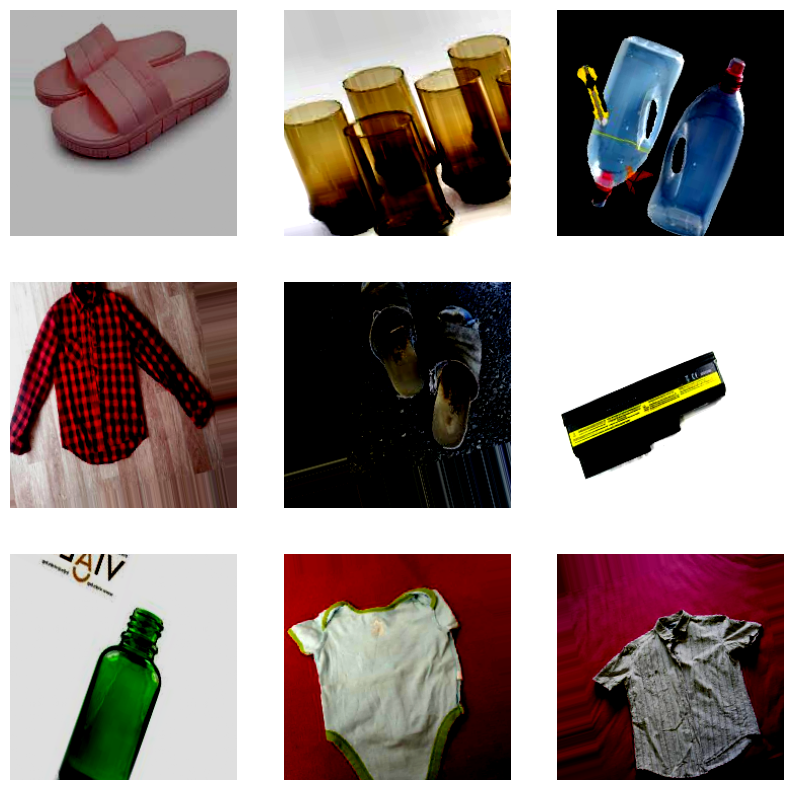

In [11]:
import matplotlib.pyplot as plt

images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

(np.float64(-0.5), np.float64(511.5), np.float64(383.5), np.float64(-0.5))

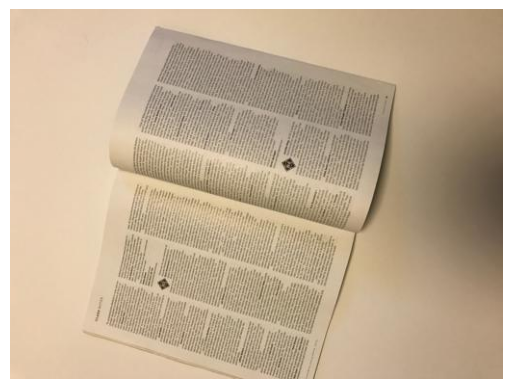

In [12]:
import cv2
import matplotlib.pyplot as plt

img_path = dataset_path + "/paper/" + os.listdir(dataset_path + "/paper")[0]

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")

In [13]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
base_model.trainable = False

In [15]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)

x = Dropout(0.5)(x)

predictions = Dense(train_generator.num_classes, activation='softmax')(x)

In [16]:
model = Model(inputs=base_model.input, outputs=predictions)

In [17]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,589,004 (9.88 MB)

 Trainable params: 331,020 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=2,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

In [20]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=7,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/7
388/388 ━━━━━━━━━━━━━━━━━━━━ 817s 2s/step - accuracy: 0.6687 - loss: 1.1093 - val_accuracy: 0.8290 - val_loss: 0.5687 - learning_rate: 1.0000e-04
Epoch 2/7
388/388 ━━━━━━━━━━━━━━━━━━━━ 861s 2s/step - accuracy: 0.8457 - loss: 0.5105 - val_accuracy: 0.8581 - val_loss: 0.4277 - learning_rate: 1.0000e-04
Epoch 3/7
388/388 ━━━━━━━━━━━━━━━━━━━━ 803s 2s/step - accuracy: 0.8757 - loss: 0.4020 - val_accuracy: 0.8771 - val_loss: 0.3758 - learning_rate: 1.0000e-04
Epoch 4/7
388/388 ━━━━━━━━━━━━━━━━━━━━ 840s 2s/step - accuracy: 0.8892 - loss: 0.3566 - val_accuracy: 0.8797 - val_loss: 0.3509 - learning_rate: 1.0000e-04
Epoch 5/7
388/388 ━━━━━━━━━━━━━━━━━━━━ 806s 2s/step - accuracy: 0.9022 - loss: 0.3237 - val_accuracy: 0.8761 - val_loss: 0.3717 - learning_rate: 1.0000e-04
Epoch 6/7
388/388 ━━━━━━━━━━━━━━━━━━━━ 832s 2s/step - accuracy: 0.9083 - loss: 0.3002 - val_accuracy: 0.8861 - val_loss: 0.3301 - learning_rate: 1.0000e-04
Epoch 7/7
388/388 ━━━━━━━━━━━━━━━━━━━━ 798s 2s/step - accuracy: 

In [21]:
model.save("garbage_classifier.keras")

In [37]:
!ls

garbage_classifier.keras  sample_data


In [35]:
from google.colab import files
files.download("garbage_classifier.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    save_best_only=True,
    monitor='val_accuracy'
)

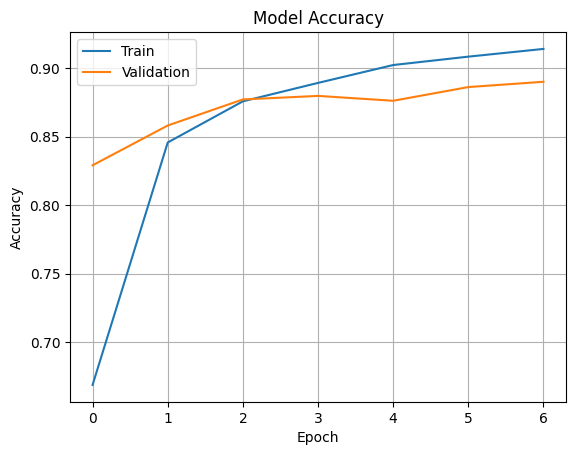

In [23]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])
plt.grid()
plt.show()

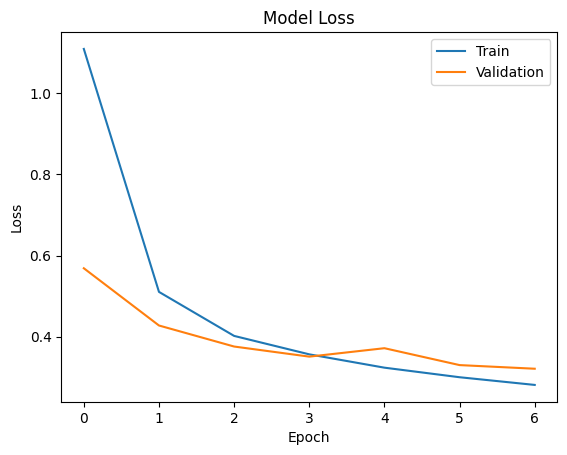

In [24]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

In [25]:
loss, accuracy = model.evaluate(validation_generator)

print("Loss:", loss)
print(f"Validation Accuracy: {accuracy*100:.2f}%")

97/97 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.8929 - loss: 0.3276
Loss: 0.32757875323295593
Validation Accuracy: 89.29%


In [26]:
import numpy as np

y_pred = model.predict(validation_generator)

y_pred_classes = np.argmax(y_pred, axis=1)

97/97 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step


In [27]:
y_true = validation_generator.classes

In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)

print(cm)

[[ 172    0    1    1    0    2   11    1    1    0    0    0]
 [   0  192    0    2    1    0    0    0    1    1    0    0]
 [   1    0   97    1    0    2   15    0    2    1    0    2]
 [   0    0    0  151   11    0    1   10    2    1    1    1]
 [   0    2    0    1 1054    0    1    1    0    5    1    0]
 [   4    7    2    0    0   92    6    0    7    2    1    4]
 [   1    1    2    2    2    1  120    6    9    2    1    6]
 [   1    1    0    3    4    0    0  192    4    1    2    2]
 [   3    1    0    1    0    2   11    3  137    0    4   11]
 [   0    4    0    1   10    0    4    0    2  374    0    0]
 [   1    3    0    0    4    0    0    3    5    2  119    2]
 [   0    2    3    0    1    2   19    3   39    0    3   83]]


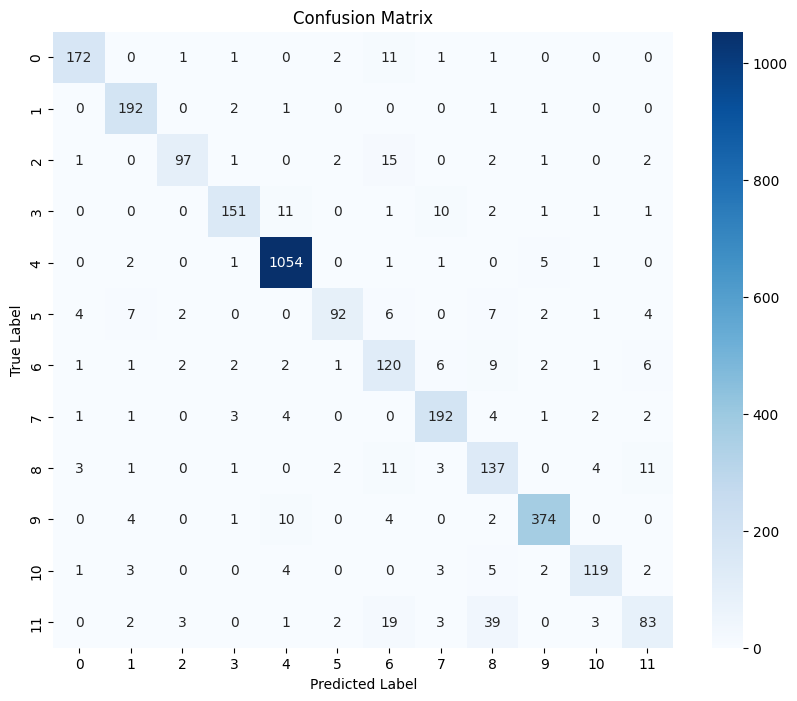

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.show()

In [30]:
from sklearn.metrics import classification_report

class_names = list(train_generator.class_indices.keys())

print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
))

              precision    recall  f1-score   support

     battery       0.94      0.91      0.92       189
  biological       0.90      0.97      0.94       197
 brown-glass       0.92      0.80      0.86       121
   cardboard       0.93      0.85      0.89       178
     clothes       0.97      0.99      0.98      1065
 green-glass       0.91      0.74      0.81       125
       metal       0.64      0.78      0.70       153
       paper       0.88      0.91      0.90       210
     plastic       0.66      0.79      0.72       173
       shoes       0.96      0.95      0.95       395
       trash       0.90      0.86      0.88       139
 white-glass       0.75      0.54      0.62       155

    accuracy                           0.90      3100
   macro avg       0.86      0.84      0.85      3100
weighted avg       0.90      0.90      0.90      3100



1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


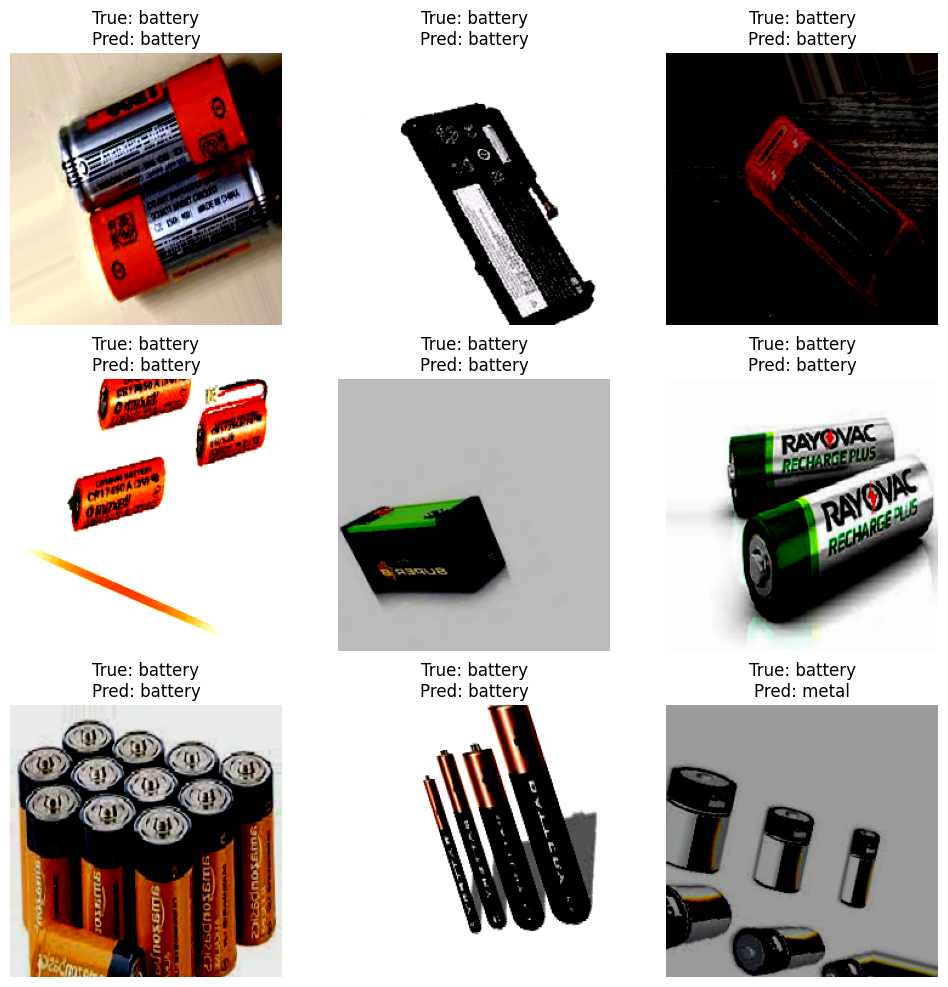

In [31]:
images, labels = next(validation_generator)

predictions = model.predict(images)

plt.figure(figsize=(12,12))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    pred = class_names[np.argmax(predictions[i])]

    true = class_names[np.argmax(labels[i])]

    plt.title(f"True: {true}\nPred: {pred}")

    plt.axis("off")

plt.show()

In [32]:
import gradio as gr
import cv2
import numpy as np

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

class_names = list(train_generator.class_indices.keys())

def predict(image):

    # resize
    img = cv2.resize(image, (224,224))

    # preprocessing
    img = preprocess_input(img)

    # expand dimensions
    img = np.expand_dims(img, axis=0)

    # prediction
    prediction = model.predict(img)

    # class
    label = class_names[np.argmax(prediction)]

    # confidence
    confidence = np.max(prediction)

    return f"{label} ({confidence:.2f})"

interface = gr.Interface(
    fn=predict,
    inputs=gr.Image(),
    outputs="text",
    title="Garbage Classification AI"
)

interface.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://b03f01e82e2bdb3e9e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://b03f01e82e2bdb3e9e.gradio.live
